# Bitcoin Market Sentiment and Trader Performance Analysis

## Objective

The objective of this project is to investigate the relationship between Bitcoin market sentiment and trader performance using historical Hyperliquid trading data.

Two datasets were analyzed:

1. Bitcoin Fear & Greed Index
2. Hyperliquid Historical Trader Data

The analysis aims to answer the following questions:

- Does market sentiment influence trader profitability?
- Are traders more successful during Fear or Greed periods?
- Does trader risk-taking behavior change with sentiment?
- Which assets perform best under different market conditions?
- Can sentiment be used to improve trading strategies?

---

## Dataset Summary

### Dataset 1: Bitcoin Fear & Greed Index

Features:
- Date
- Sentiment Classification
- Fear & Greed Score

### Dataset 2: Hyperliquid Historical Trades

Features:
- Account
- Coin
- Execution Price
- Trade Size
- Direction
- Closed PnL
- Fees
- Timestamp

---

## Methodology

1. Load and inspect datasets
2. Clean and preprocess data
3. Merge sentiment and trading information
4. Perform exploratory data analysis
5. Analyze profitability across sentiment regimes
6. Analyze win rates and position sizing
7. Investigate coin-level and trader-level performance
8. Generate actionable trading insights

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


# Data Loading

In this section we load both datasets and inspect their structure.

The goal is to:

- Understand available features
- Identify missing values
- Verify dataset quality
- Understand data types before cleaning

In [2]:
trades = pd.read_csv("data/historical_data.csv")

print("Shape:", trades.shape)

Shape: (211224, 16)


In [3]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [4]:
trades.columns.tolist()

['Account',
 'Coin',
 'Execution Price',
 'Size Tokens',
 'Size USD',
 'Side',
 'Timestamp IST',
 'Start Position',
 'Direction',
 'Closed PnL',
 'Transaction Hash',
 'Order ID',
 'Crossed',
 'Fee',
 'Trade ID',
 'Timestamp']

In [5]:
trades.info()

<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 non-null  str    
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  str    
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  str    
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(8), int64(1

In [6]:
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [7]:
trades.describe()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


In [8]:
sentiment = pd.read_csv("data/fear_greed_index.csv")

print("Shape:", sentiment.shape)

Shape: (2644, 4)


In [9]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [10]:
sentiment.info()

<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   timestamp       2644 non-null   int64
 1   value           2644 non-null   int64
 2   classification  2644 non-null   str  
 3   date            2644 non-null   str  
dtypes: int64(2), str(2)
memory usage: 82.8 KB


# Data Cleaning and Preparation

Before analysis, both datasets must be standardized.

Key preprocessing steps:

1. Convert timestamps into datetime format
2. Create a common date key
3. Merge sentiment and trade data
4. Validate merge quality

This ensures every trade is associated with the corresponding market sentiment.

In [11]:
trades["Timestamp IST"] = pd.to_datetime(
    trades["Timestamp IST"],
    dayfirst=True
)

In [12]:
trades["Date"] = trades["Timestamp IST"].dt.date

In [13]:
sentiment["date"] = pd.to_datetime(
    sentiment["date"]
)

In [14]:
sentiment["Date"] = sentiment["date"].dt.date

In [15]:
merged = trades.merge(
    sentiment[
        ["Date", "classification", "value"]
    ],
    on="Date",
    how="left"
)

In [16]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0


In [17]:
merged["classification"].isnull().sum()

np.int64(6)

# Exploratory Data Analysis

The first step is to understand how trades are distributed across different sentiment regimes.

We investigate:

- Number of trades under each sentiment
- Distribution of sentiment categories
- General market participation behavior

In [18]:
merged["classification"].value_counts()

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

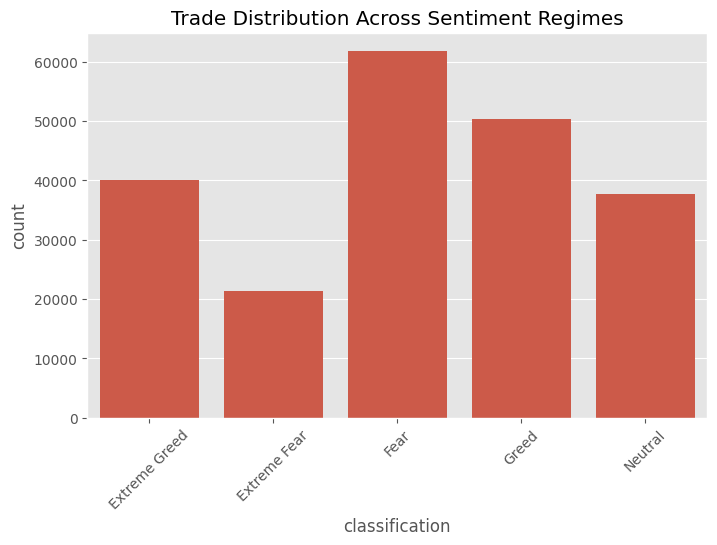

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="classification",
    data=merged
)

plt.title("Trade Distribution Across Sentiment Regimes")

plt.xticks(rotation=45)

plt.show()

# Profitability Analysis

This section examines whether market sentiment affects trader profitability.

Metrics analyzed:

- Average Profit/Loss
- Median Profit/Loss
- Total Profit/Loss
- Number of Trades

Understanding profitability across sentiment regimes can reveal favorable market conditions.

In [20]:
sentiment_profitability = merged.groupby(
    "classification"
)["Closed PnL"].agg(
    ["count","mean","median","sum"]
)

sentiment_profitability.sort_values(
    "sum",
    ascending=False
)

,count,mean,median,sum
classification,,,,
Fear,61837,54.290400,0.0,3.357155e+06
Extreme Greed,39992,67.892861,0.0,2.715171e+06
Greed,50303,42.743559,0.0,2.150129e+06
Neutral,37686,34.307718,0.0,1.292921e+06
Extreme Fear,21400,34.537862,0.0,7.391102e+05


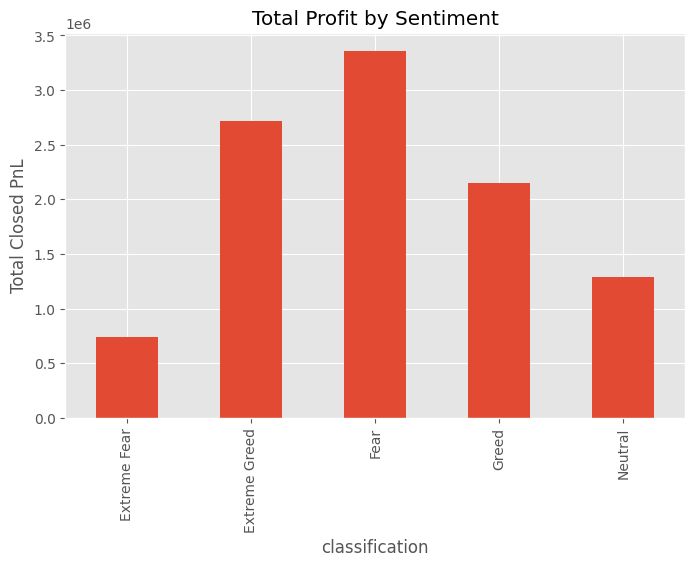

In [21]:
plt.figure(figsize=(8,5))

merged.groupby(
    "classification"
)["Closed PnL"].sum().plot(
    kind="bar"
)

plt.title(
    "Total Profit by Sentiment"
)

plt.ylabel(
    "Total Closed PnL"
)

plt.show()

## Key Observation

Extreme Greed generated the highest average profit per trade.

Fear generated the highest aggregate profit, indicating a larger number of profitable opportunities during fearful market conditions.

This suggests that both optimistic and pessimistic market regimes create distinct trading advantages.

# Win Rate Analysis

Profitability alone does not provide a complete picture.

Win rate measures the percentage of trades that generate positive profits.

This analysis helps determine whether traders are consistently profitable or rely on a small number of large winning trades.

In [22]:
merged["Win"] = (
    merged["Closed PnL"] > 0
)

In [23]:
win_rate = (
    merged.groupby(
        "classification"
    )["Win"]
    .mean()
    * 100
)

win_rate

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: Win, dtype: float64

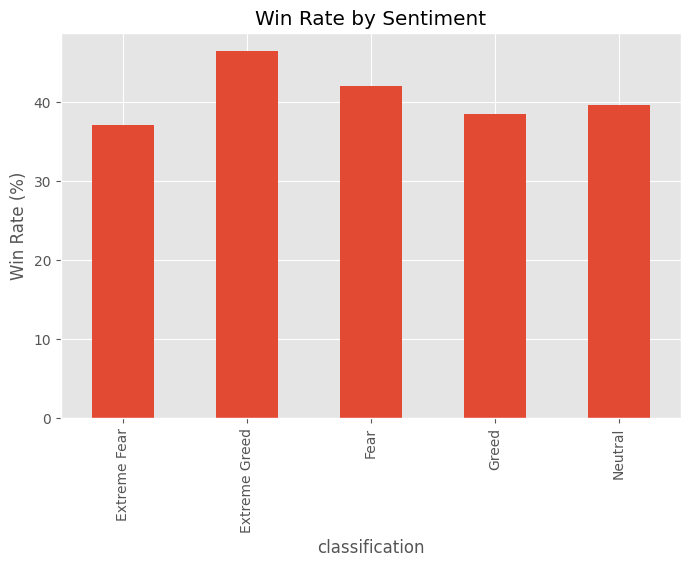

In [24]:
plt.figure(figsize=(8,5))

win_rate.plot(
    kind="bar"
)

plt.title(
    "Win Rate by Sentiment"
)

plt.ylabel(
    "Win Rate (%)"
)

plt.show()

## Key Observation

Extreme Greed achieved the highest win rate.

Despite positive overall profitability, win rates remain below 50%, suggesting that successful traders rely on larger winning trades rather than a high percentage of winning positions.

# Position Size Analysis

Trader profitability is only one aspect of market behavior.

Another important question is:

**Do traders take larger positions during Fear or Greed periods?**

Average trade size acts as a proxy for risk appetite and conviction.

In [25]:
position_size = merged.groupby(
    "classification"
)["Size USD"].mean()

position_size

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64

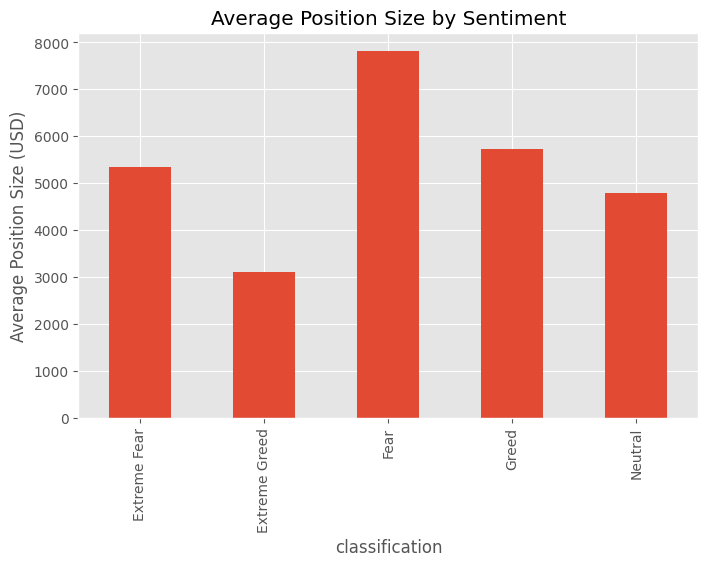

In [26]:
plt.figure(figsize=(8,5))

position_size.plot(
    kind="bar"
)

plt.title(
    "Average Position Size by Sentiment"
)

plt.ylabel(
    "Average Position Size (USD)"
)

plt.show()

## Key Observation

Fear periods exhibited the largest average position sizes.

This suggests traders deploy larger amounts of capital during pessimistic market conditions, potentially seeking discounted entry opportunities.

# Directional Performance Analysis

This section evaluates how trading direction behaves under different sentiment regimes.

The objective is to determine whether certain directional strategies perform better under specific market conditions.

In [31]:
direction_analysis = pd.pivot_table(
    merged,
    values="Closed PnL",
    index="classification",
    columns="Direction",
    aggfunc="mean"
)

direction_analysis

Direction,Auto-Deleveraging,Buy,Close Long,Close Short,Liquidated Isolated Short,Long > Short,Open Long,Open Short,Sell,Settlement,Short > Long,Spot Dust Conversion
classification,,,,,,,,,,,,
Extreme Fear,NaN,0.0,81.197371,123.400238,NaN,1.331956,0.0,0.0,-135.021730,NaN,-1932.516940,0.0
Extreme Greed,NaN,0.0,61.830783,28.970490,NaN,120.600968,0.0,0.0,290.572354,NaN,11.771238,0.0
Fear,NaN,0.0,83.000111,207.676658,NaN,4.795642,0.0,0.0,-3.141217,NaN,1115.943156,0.0
Greed,7184.807003,0.0,88.958554,55.195496,-12752.91304,22.711911,0.0,0.0,128.022106,-29.215368,100.665716,0.0
Neutral,NaN,0.0,52.815787,94.796313,NaN,47.332193,0.0,0.0,89.517239,NaN,-11.945100,0.0


## Key Observation

Directional profitability varies substantially across sentiment regimes.

This indicates that market sentiment may influence the effectiveness of long and short trading strategies.

# Coin-Level Analysis

Market sentiment may impact different assets in different ways.

This section identifies:

- Top-performing assets
- Asset resilience across sentiment regimes
- Potential trading opportunities

In [32]:
top_coins = (
    merged.groupby("Coin")["Closed PnL"]
    .sum()
    .sort_values(
        ascending=False
    )
    .head(10)
)

top_coins

Coin
@107       2.783913e+06
HYPE       1.948485e+06
SOL        1.639556e+06
ETH        1.319979e+06
BTC        8.680447e+05
MELANIA    3.903511e+05
ENA        2.173295e+05
SUI        1.992688e+05
ZRO        1.837778e+05
DOGE       1.475432e+05
Name: Closed PnL, dtype: float64

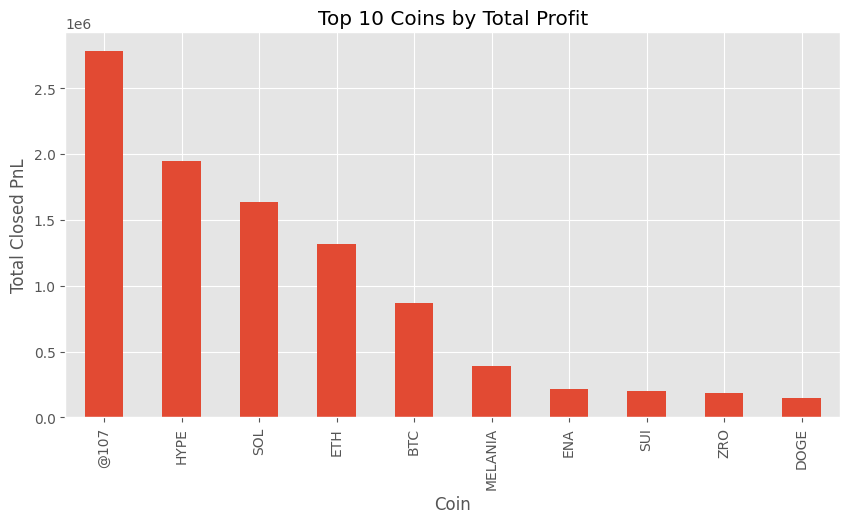

In [33]:
plt.figure(figsize=(10,5))

top_coins.plot(
    kind="bar"
)

plt.title(
    "Top 10 Coins by Total Profit"
)

plt.ylabel(
    "Total Closed PnL"
)

plt.show()

In [34]:
coin_counts = merged["Coin"].value_counts()

major_coins = coin_counts[
    coin_counts > 1000
].index

In [35]:
filtered = merged[
    merged["Coin"].isin(
        major_coins
    )
]

In [36]:
coin_sentiment = pd.pivot_table(
    filtered,
    values="Closed PnL",
    index="Coin",
    columns="classification",
    aggfunc="mean"
)

coin_sentiment

classification,Extreme Fear,Extreme Greed,Fear,Greed,Neutral
Coin,,,,,
@107,-89.588788,191.158211,-2.291257,86.251763,52.150107
@142,15.529335,NaN,1.844487,1.677434,14.747182
BERA,64.313320,NaN,-0.081313,202.047489,-189.623480
BTC,1.731921,41.413264,48.900673,15.949612,34.921175
ETH,196.927660,-20.758928,236.864764,98.219366,46.753294
FARTCOIN,-244.272754,21.301449,-11.368853,18.718423,-3.060023
FTT,37.156913,2.793807,26.669028,2.727470,11.469584
HYPE,46.904438,28.098989,30.063552,24.569012,17.322803
MELANIA,218.338940,-70.399143,99.168325,59.748579,82.596900


## Key Observation

BTC, ETH, and SOL demonstrated strong profitability across multiple sentiment regimes.

These assets appear more resilient than many alternative assets and may offer better risk-adjusted opportunities.

# Trader-Level Analysis

Not all traders perform equally.

This section identifies:

- Top-performing traders
- Profit concentration
- Trading activity levels

In [37]:
top_traders = merged.groupby(
    "Account"
).agg(
    {
        "Closed PnL":"sum",
        "Trade ID":"count"
    }
)

top_traders.columns = [
    "Total_PnL",
    "Trades"
]

In [38]:
top_traders.sort_values(
    "Total_PnL",
    ascending=False
).head(10)

,Total_PnL,Trades
Account,,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2.143383e+06,14733
0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,3818
0xbaaaf6571ab7d571043ff1e313a9609a10637864,9.401638e+05,21192
0x513b8629fe877bb581bf244e326a047b249c4ff1,8.404226e+05,12236
0xbee1707d6b44d4d52bfe19e41f8a828645437aab,8.360806e+05,40184
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,6.777471e+05,4356
0x72743ae2822edd658c0c50608fd7c5c501b2afbd,4.293556e+05,1590
0x430f09841d65beb3f27765503d0f850b8bce7713,4.165419e+05,1237
0x72c6a4624e1dffa724e6d00d64ceae698af892a0,4.030115e+05,1430


In [39]:
best_traders = (
    top_traders
    .sort_values(
        "Total_PnL",
        ascending=False
    )
    .head(10)
)

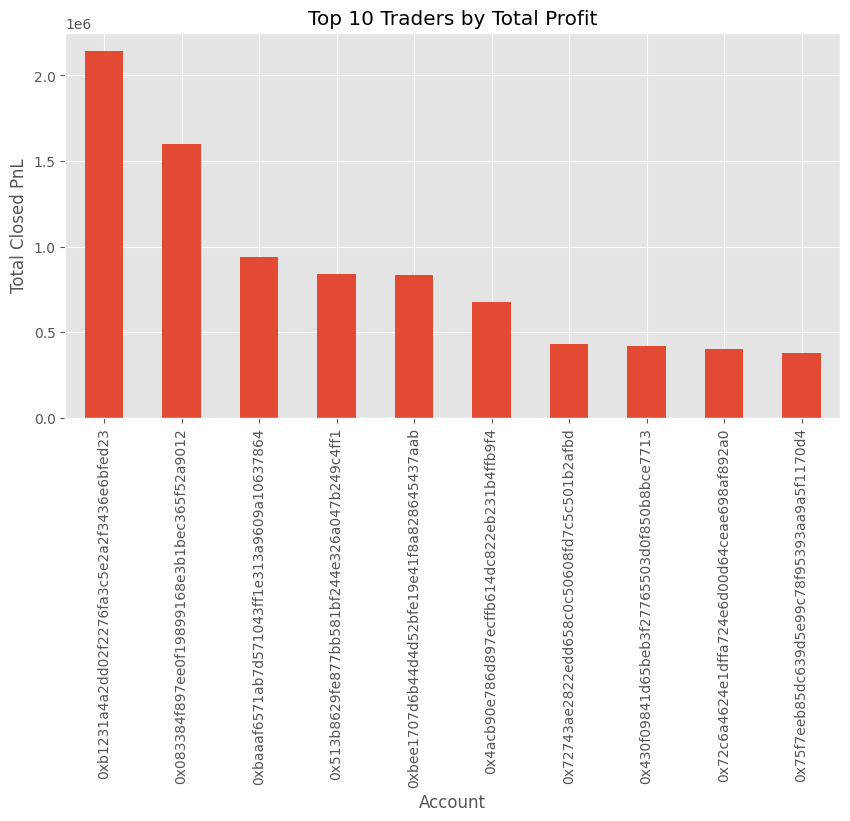

In [40]:
plt.figure(figsize=(10,5))

best_traders["Total_PnL"].plot(
    kind="bar"
)

plt.title(
    "Top 10 Traders by Total Profit"
)

plt.ylabel(
    "Total Closed PnL"
)

plt.show()

In [41]:
top_traders["Total_PnL"].describe()

count    3.200000e+01
mean     3.217800e+05
std      4.948276e+05
min     -1.676211e+05
25%      4.689324e+04
50%      1.176551e+05
75%      4.063941e+05
max      2.143383e+06
Name: Total_PnL, dtype: float64

## Key Observation

Profit generation is highly concentrated among a small subset of traders.

The gap between mean and median profitability indicates that a relatively small number of highly successful traders account for a disproportionate share of total profits.

# Profitability Summary Table

This table combines multiple metrics into a single view to compare sentiment regimes.

In [42]:
summary_table = merged.groupby(
    "classification"
).agg(
    Avg_PnL=("Closed PnL","mean"),
    Total_PnL=("Closed PnL","sum"),
    Avg_Size=("Size USD","mean"),
    Win_Rate=("Win","mean")
)

summary_table

,Avg_PnL,Total_PnL,Avg_Size,Win_Rate
classification,,,,
Extreme Fear,34.537862,7.391102e+05,5349.731843,0.370607
Extreme Greed,67.892861,2.715171e+06,3112.251565,0.464943
Fear,54.290400,3.357155e+06,7816.109931,0.420768
Greed,42.743559,2.150129e+06,5736.884375,0.384828
Neutral,34.307718,1.292921e+06,4782.732661,0.396991


# Correlation Analysis

Correlation analysis helps identify relationships between numerical variables and provides additional context for trader behavior.

In [43]:
numeric = merged.select_dtypes(
    include=np.number
)

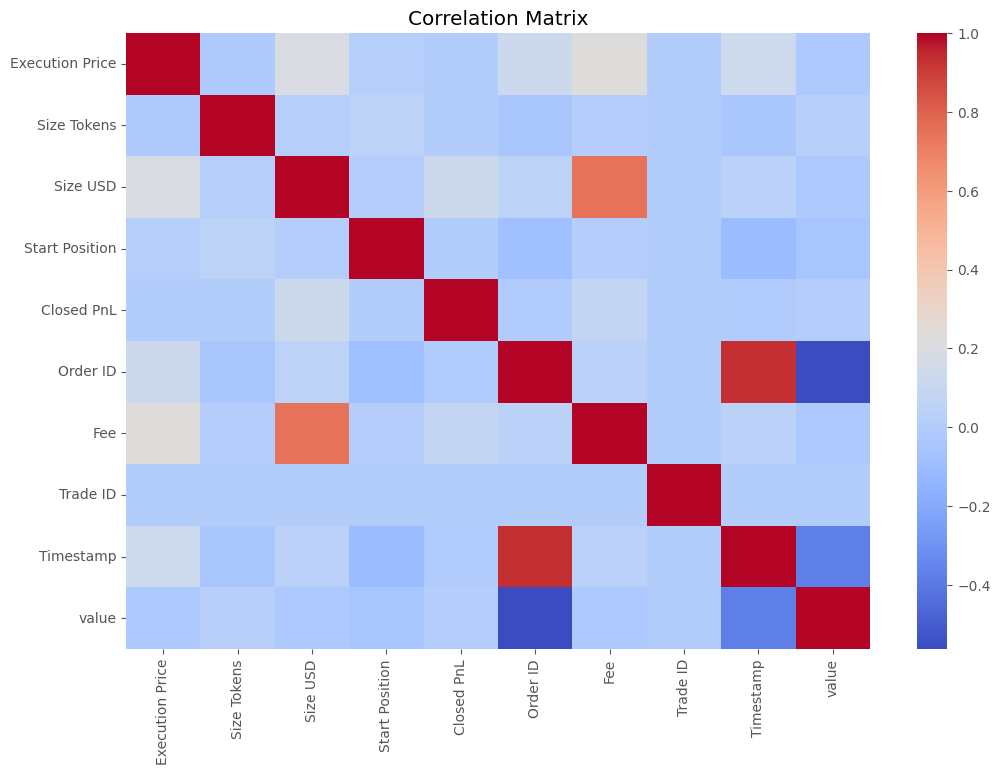

In [44]:
plt.figure(figsize=(12,8))

sns.heatmap(
    numeric.corr(),
    cmap="coolwarm",
    annot=False
)

plt.title(
    "Correlation Matrix"
)

plt.show()

# Strategy Recommendations

Based on the analysis, the following observations may help improve trading decisions.

## Recommendation 1

Extreme Greed periods exhibit the highest average profitability and win rates.

A sentiment-aware trading framework could increase exposure during these conditions.

## Recommendation 2

Fear periods generate the highest aggregate profits and largest position sizes.

Monitoring fearful market conditions may uncover attractive trading opportunities.

## Recommendation 3

BTC, ETH, and SOL demonstrate strong performance across multiple sentiment regimes and may provide more resilient trading opportunities.

## Recommendation 4

Risk management remains critical because overall profitability appears to be driven by a relatively small number of highly successful trades.

# Conclusion

This study analyzed 211,224 Hyperliquid trades alongside Bitcoin Fear & Greed sentiment data.

Key findings include:

1. Extreme Greed produced the highest average profitability.
2. Fear generated the highest aggregate profits.
3. Traders deployed larger position sizes during Fear periods.
4. More than 50% of trades closed with zero PnL, resulting in a median PnL of zero.
5. BTC, ETH, and SOL demonstrated resilience across multiple sentiment regimes.
6. Profit generation was concentrated among a relatively small number of traders.

Overall, the results suggest that market sentiment has a measurable impact on trading performance, risk-taking behavior, and asset profitability.